# The coupled spatio-sequential model: simulate, enumerate, fit

One pass through the fourth problem class (issue #290): a Potts prior over
class labels on a spatial graph, one hidden Markov chain per class, and a
*gated* emission that lets the class a node belongs to say which chain emits
its observations. Every number printed here is pinned by the regression suite
(`tests/regression/{sim,likelihood,search}/test_spatio_sequential*.py`); this
notebook states nothing the suite does not.

**Scope.** The canonical instance is small enough to enumerate --- a 2x2 open
lattice, two classes, two states, six positions, 65,536 joint states --- so
the evidence, the posteriors and the MAP labelling have exact values. Past
enumeration a planted 10x10 lattice is where the label solvers and the
annealed start are measured. Categorical emissions throughout; the Gaussian
and count families the ticket names are one constructor away and are not
shown.

In [1]:
import numpy as np
from snakes_and_ladders.likelihood.spatio_sequential import (
    enumerate_spatio_sequential,
    log_evidence_by_forward,
    map_labelling,
)
from snakes_and_ladders.opt.schedule import Exponential
from snakes_and_ladders.search.spatio_sequential import (
    LabelSolver,
    fit_spatio_sequential,
    graph_burn_in,
    label_accuracy,
)
from snakes_and_ladders.sim.fixtures import fixture
from snakes_and_ladders.sim.spatio_sequential import simulate_spatio_sequential

np.set_printoptions(precision=3, suppress=True)

## The fixture

The CI fixture of the coupled problem declares the truth. One generator draws the
labels from the Potts prior by the heat bath, each class's chain from its
initial distribution and the circulant transition, and every observation from
the family of the node's class at the state of that class's chain.

In [2]:
params = fixture("spatio_sequential", "ci").params
data = simulate_spatio_sequential(params, np.random.default_rng(1))
print(
    "nodes",
    params.graph.n_nodes,
    "classes",
    params.n_classes,
    "states",
    params.n_states,
    "positions",
    params.n_positions,
)
print("labels     ", data.labels)
print("chains     ", data.states.tolist())
print("observations (positions x nodes)")
print(data.observations)

nodes 4 classes 2 states 2 positions 6
labels      [1 1 1 0]
chains      [[0, 0, 0, 1, 1, 0], [0, 1, 1, 0, 1, 1]]
observations (positions x nodes)
[[2 0 1 0]
 [1 1 0 0]
 [1 2 1 0]
 [2 2 2 1]
 [1 1 1 1]
 [2 1 0 0]]


## The oracle, two ways

Enumeration sums the joint over every labelling and every joint chain path.
It is pinned against a route that shares no code with it: given the labels
the classes decouple, so the evidence is a sum over labellings of the
per-class forward recursion.

In [3]:
exact = enumerate_spatio_sequential(params, data.observations)
forward = log_evidence_by_forward(params, data.observations)
print("log evidence by enumeration", round(exact.log_evidence, 10))
print("log evidence by forward     ", round(forward, 10))
print("relative gap                ", abs(exact.log_evidence - forward) / abs(forward))
print("label posterior p(l_n = m | x)")
print(exact.label_posterior)
print("MAP labelling", map_labelling(params, data.observations), " drawn", data.labels)

log evidence by enumeration -27.3318388129
log evidence by forward      -27.3318388129
relative gap                 0.0
label posterior p(l_n = m | x)
[[0.067 0.933]
 [0.097 0.903]
 [0.168 0.832]
 [0.727 0.273]]
MAP labelling [1 1 1 0]  drawn [1 1 1 0]


## The label block against enumeration

With the parameters held at the truth, block ascent on the labels is a
coordinate ascent on `log p(x, l | theta)`. From the planted labels each of the
three solvers reaches the enumerated MAP labelling on most draws; the joint
never decreases.

In [4]:
schedule = Exponential(2.0, 0.2, 12)
for solver in LabelSolver:
    hits = 0
    for seed in range(6):
        draw = simulate_spatio_sequential(params, np.random.default_rng(10 + seed))
        target = map_labelling(params, draw.observations)
        fit = fit_spatio_sequential(
            params,
            draw.observations,
            np.random.default_rng(seed),
            solver=solver,
            n_blocks=6,
            labels=draw.labels,
            fit_parameters=False,
            wolff_schedule=schedule,
        )
        assert (np.diff(fit.log_likelihoods) >= -1e-9).all()
        hits += int(np.array_equal(fit.labels, target))
    print(
        f"{solver.value:16s} reaches the enumerated MAP from the planted labels on {hits} of 6 draws"
    )

alpha_expansion  reaches the enumerated MAP from the planted labels on 5 of 6 draws


icm              reaches the enumerated MAP from the planted labels on 5 of 6 draws


wolff            reaches the enumerated MAP from the planted labels on 5 of 6 draws


## Block ascent with the parameters fitted

Now the emissions, the initial distributions and the shared self-transition
are re-estimated each block. The printed trajectory is `log p(x, l | theta)`
up to the Potts normalizer after every half block, and it does not decrease.

In [5]:
fit = fit_spatio_sequential(
    params, data.observations, np.random.default_rng(0), n_blocks=8
)
print("joint after every half block")
print(fit.log_likelihoods)
print("non-decreasing:", bool((np.diff(fit.log_likelihoods) >= -1e-9).all()))
print(
    "fitted self-transition",
    round(fit.params.self_transition, 4),
    " true",
    params.self_transition,
)
print("fitted labels", fit.labels, " drawn", data.labels)

joint after every half block
[-23.838 -20.107 -20.107 -19.979 -19.979 -19.942 -19.942 -19.926 -19.926
 -19.917 -19.917 -19.912 -19.912 -19.908 -19.908 -19.906 -19.906]
non-decreasing: True
fitted self-transition 0.6038  true 0.7
fitted labels [1 1 1 0]  drawn [1 1 1 0]


## Past enumeration: the three solvers, and the start

A planted 10x10 lattice with weak emissions, so the prior matters. With the
parameters known the label problem is easy. From a uniform start with the
true parameters as EM's starting point, every solver freezes --- the trap is
the parameters, not the labels --- and the annealed start `Graph_BurnIn++`,
seeded by `Emission_Mixture++`, is what recovers them.

In [6]:
lattice = fixture("spatio_sequential", "stress").params
side = lattice.graph.shape[0]
planted = (np.arange(side * side) % side < side // 2).astype(np.int64)
rows = {
    "known parameters": [],
    **{solver.value: [] for solver in LabelSolver},
    "burn-in start": [],
}
for seed in range(6):
    draw = simulate_spatio_sequential(
        lattice, np.random.default_rng(50 + seed), labels=planted
    )
    known = fit_spatio_sequential(
        lattice,
        draw.observations,
        np.random.default_rng(seed),
        n_blocks=10,
        labels=planted,
        fit_parameters=False,
    )
    rows["known parameters"].append(label_accuracy(known.labels, planted, 2))
    for solver in LabelSolver:
        cold = fit_spatio_sequential(
            lattice,
            draw.observations,
            np.random.default_rng(seed),
            solver=solver,
            n_blocks=10,
            wolff_schedule=Exponential(3.0, 0.3, 30),
        )
        rows[solver.value].append(label_accuracy(cold.labels, planted, 2))
    warm = graph_burn_in(
        lattice,
        draw.observations,
        np.random.default_rng(seed),
        Exponential(4.0, 1.0, 30),
    )
    polished = fit_spatio_sequential(
        warm.params,
        draw.observations,
        np.random.default_rng(seed),
        n_blocks=10,
        labels=warm.labels,
    )
    rows["burn-in start"].append(label_accuracy(polished.labels, planted, 2))
print("label accuracy up to permutation, mean over six planted draws")
for name, values in rows.items():
    print(f"  {name:18s} {np.mean(values):.3f}")

label accuracy up to permutation, mean over six planted draws
  known parameters   0.987
  alpha_expansion    0.662
  icm                0.783
  wolff              0.683
  burn-in start      0.973


## Seeding each state's emission parameters

Everything above starts the emissions somewhere and does not ask where. Issue
#541 asks: drop the spatial coupling and the chain from the coupled model and
each observation is one draw from a mixture over the `M x K` (class, state)
pairs, which is the surface a seeding of the emission parameters actually
sees. Eight candidates are compared there, all through one seam --- each picks
`M x K` observations and `ComponentsAt` places a component on each --- so what
separates them is the choice and nothing after it.

The instance here is the **count fixture's `ci` model**, four components, where
the projection is cheap enough to plot. The key model's 100 components are
past this notebook's budget: that sweep is
`docs/experiments/009-projection-emission-seedings.md`, and
`tests/regression/search/test_projection_seeding.py` pins its ordering.

Cost is counted in **passes over the data**, one pass being every observation
scored under every component. A fit iteration spends one on its E step; the M
step is not counted, because every candidate pays the identical one.

classes 2 states 2 components 4 observations 4000


the generating parameters assign 0.78 of observations correctly


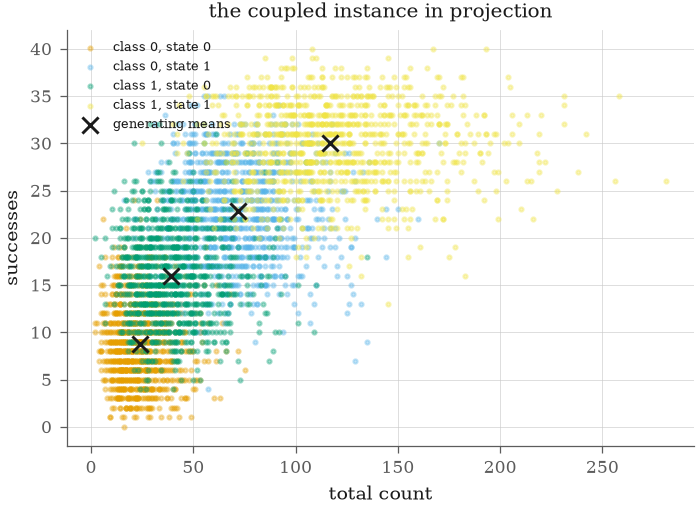

In [7]:
import matplotlib.pyplot as plt
from snakes_and_ladders.opt.budget import Budget
from snakes_and_ladders.opt.mixture import mixture_log_likelihood, responsibilities
from snakes_and_ladders.qa.style import discrete_palette, notebook_style
from snakes_and_ladders.search.projection import (
    SEEDINGS,
    CountPairAt,
    fit_projection,
    flatten,
    project,
)
from snakes_and_ladders.sim.count_pairs import binned_model
import torch

counts = fixture("spatio_sequential_counts", "ci").params
model = binned_model(counts.model, 1)
projected = project(model, 4000, np.random.default_rng([541, 0]))
truth = flatten(model)
at = CountPairAt(
    float(truth.total.dispersion.mean()),
    float(truth.successes.concentration.mean()),
    projected.trials,
)
print(
    "classes",
    model.n_classes,
    "states",
    model.n_states,
    "components",
    projected.n_components,
    "observations",
    projected.n_samples,
)

values = torch.as_tensor(projected.observations, dtype=torch.float64)
log_weight = torch.log(torch.as_tensor(projected.weights, dtype=torch.float64))
at_truth = float(mixture_log_likelihood(values, log_weight, truth))
bayes = float(
    np.mean(
        responsibilities(values, log_weight, truth).argmax(dim=1).numpy()
        == projected.components
    )
)
print(f"the generating parameters assign {bayes:.2f} of observations correctly")

palette = discrete_palette(projected.n_components)
with notebook_style():
    figure, axis = plt.subplots(figsize=(5.4, 3.6))
    for component in range(projected.n_components):
        drawn = projected.components == component
        axis.scatter(
            projected.observations[drawn, 0],
            projected.observations[drawn, 1],
            s=4,
            alpha=0.35,
            color=palette[component],
            label=f"class {component // model.n_states}, state {component % model.n_states}",
        )
    axis.scatter(
        truth.total.mean.numpy(),
        truth.successes.mean.numpy(),
        marker="x",
        s=60,
        color="0.1",
        label="generating means",
    )
    axis.set_xlabel("total count")
    axis.set_ylabel("successes")
    axis.set_title("the coupled instance in projection")
    axis.legend(fontsize=6, loc="upper left")
    plt.show()

The four components overlap and lie along a curve the two channels' means
trace out, so none is separated from its neighbours by a threshold in either
channel alone. That is what makes the geometry the argument: a squared
Euclidean distance treats a total count and a success count alike, and the
family's own negative log-density does not.

The eight candidates, in the order the ticket states them. `prior` and `data`
are the two cheap controls; `kmeans++` is D-squared sampling under squared
Euclidean distance; `emission++` is the same scheme under the family's own
negative log-density; `burn-in` is what the coupled model's own start reduces
to here; and `hmc`, `anneal` and `tempering` sample a Gaussian mixture over the
first channel, which is an `Objective` already, and take their component means
as locations.

In [8]:
budget = Budget("passes", 6)
fits = {
    name: fit_projection(projected, name, at, budget, np.random.default_rng([541, 0]))
    for name in SEEDINGS
}
best = max(fit.log_likelihood for fit in fits.values())

print(f"{'candidate':11s} {'recovery':>8s} {'mean error':>10s} {'passes':>7s}  best within 1e-4")
for name, fit in fits.items():
    reached = "yes" if best - fit.log_likelihood <= 1e-4 * abs(best) else "no"
    print(
        f"{name:11s} {fit.recovery:8.2f} {fit.mean_error:10.2f} "
        f"{fit.seeding.passes:7.0f}  {reached}"
    )
print(f"\ngenerating parameters reach a recovery of {bayes:.2f}")
print("chain diagnostics")
for name in ("hmc", "anneal", "tempering"):
    print(f"  {name:10s} {fits[name].seeding.diagnostics}")

candidate   recovery mean error  passes  best within 1e-4
prior           0.52       0.61       0  no
data            0.66       0.39       0  no
kmeans++        0.48       0.51       1  no
emission++      0.56       0.56       1  no
burn-in         0.68       0.36       1  no
hmc             0.75       0.06     144  yes
anneal          0.75       0.06     144  yes
tempering       0.76       0.08     144  yes

generating parameters reach a recovery of 0.78
chain diagnostics
  hmc        acceptance 1.00, mean energy error 7.78e-01
  anneal     acceptance 1.00
  tempering  cold acceptance 1.00, lowest swap 0.50


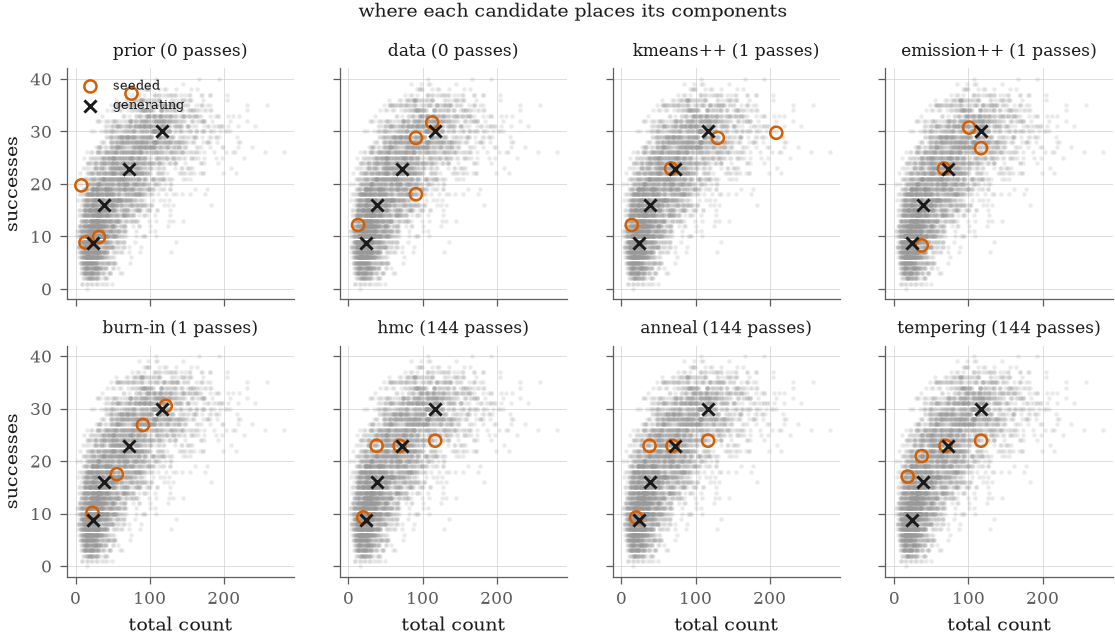

In [9]:
with notebook_style():
    figure, axes = plt.subplots(2, 4, figsize=(9.0, 4.4), sharex=True, sharey=True)
    for axis, (name, fit) in zip(axes.ravel(), fits.items()):
        axis.scatter(
            projected.observations[:, 0],
            projected.observations[:, 1],
            s=2,
            alpha=0.12,
            color="0.6",
        )
        seeded = fit.seeding.components
        axis.scatter(
            seeded.total.mean.numpy(),
            seeded.successes.mean.numpy(),
            marker="o",
            s=34,
            facecolor="none",
            edgecolor="#D55E00",
            linewidth=1.2,
            label="seeded",
        )
        axis.scatter(
            truth.total.mean.numpy(),
            truth.successes.mean.numpy(),
            marker="x",
            s=34,
            color="0.1",
            label="generating",
        )
        unit = "pass" if fit.seeding.passes == 1 else "passes"
        axis.set_title(f"{name} ({fit.seeding.passes:.0f} {unit})", fontsize=8)
    for axis in axes[-1]:
        axis.set_xlabel("total count")
    for axis in axes[:, 0]:
        axis.set_ylabel("successes")
    axes[0, 0].legend(fontsize=6, loc="upper left")
    figure.suptitle("where each candidate places its components", fontsize=9)
    plt.show()

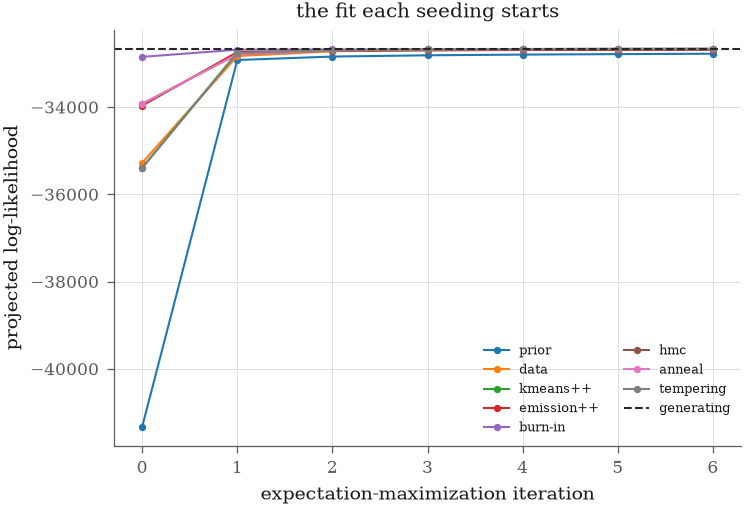

In [10]:
# The curves sit on top of each other in log-likelihood: at four components
# every candidate is within a few nats of the best after one iteration. What
# separates them is the gap below the best value seen, on a log axis.
reference = max(best, at_truth)
with notebook_style():
    figure, axis = plt.subplots(figsize=(5.4, 3.6))
    for name, fit in fits.items():
        gap = np.maximum(reference - np.asarray(fit.log_likelihoods), 1e-2)
        axis.semilogy(
            range(len(gap)),
            gap,
            marker="o",
            markersize=2.5,
            linewidth=1.0,
            label=name,
        )
    axis.set_xlabel("expectation-maximization iteration")
    axis.set_ylabel("gap below the best value seen (nats)")
    axis.set_title("the fit each seeding starts")
    axis.legend(fontsize=6, ncol=2)
    plt.show()
print(f"the generating parameters sit {reference - at_truth:.0f} nats below the best")

### What the three plots say

**The two chains and the annealed control beat every heuristic here, and cost
more than the fit they seed.** At four components and a budget of six
iterations, `hmc`, `anneal` and `tempering` reach the best projected
log-likelihood any candidate found, to a relative 1e-4, and leave 0.06 to 0.08
of relative error in a component's negative-binomial mean; no heuristic
reaches it, and the best of them leaves 0.36. Their recovery of the generating
component, 0.75 to 0.76, is within 0.03 of what the generating parameters
themselves achieve.

**The price is 144 passes against the fit's 6.** That is the case the ticket
names: a seeding whose cost approaches the fit's own is a different
proposition and is flagged rather than averaged in. Their acceptance rates
read 1.00 and their swap acceptance 0.50, which at 4,000 observations is a
chain descending a sharp surrogate rather than mixing on it --- so what these
three buy is optimization of a Gaussian mixture over the first channel, and
not a posterior draw.

**The cheap candidates do not separate on one draw and one seed.** Their
recoveries run 0.48 to 0.68 and their component-mean errors 0.36 to 0.61, and
which of them leads moves with the draw. Declaring an ordering off this figure
would be the one-seed range #447 found and rejected; the ordering that is
claimed is the key model's, over six paired instances, in
`docs/experiments/009-projection-emission-seedings.md`, with
`tests/regression/search/test_projection_seeding.py` pinning it at release.

**Where the geometry shows.** `kmeans++` puts one of its four components at a
total of about 210, where no class sits. A total count runs to 250 here and a
success count to 40, so a squared distance over the pair is dominated by the
first channel, and D-squared sampling reaches for its extreme. `emission++`,
scoring under the family's own negative log-density, places all four inside the
data. That is the textbook's reason for the substitution, visible rather than
argued.

## Further work

- **Gaussian and count emissions in this notebook (#290).** The families exist
  and the M-step identity is pinned on a Gaussian instance in the suite; the
  notebook shows the categorical case only.
- **A larger and more frustrated lattice (#290).** The 10x10 planted instance
  separates the annealed start from a cold one; whether a cluster move ever
  beats single-site descent on a harder instance is unmeasured.
- **The comparison at an equal budget through the utility (#281).** The
  solver rows above run ten blocks each; the sweeps each label block spends
  are not held equal.
- **Decoding the chains (#407).** Viterbi landed with #175; the state
  posteriors are computed here and no path is decoded from them.
- **The seeding comparison at the key model inside this notebook (#541).**
  The 100-component projection costs 10 s an iteration, so the sweep runs
  in `docs/experiments/` and at the release tier; what is shown here is
  the four-component instance.
- **Spectral seeding (#554).** Hsu, Kakade and Zhang's moment inversion
  is the sixth candidate the ticket names and no implementation exists,
  so it is not in the table above.
- **The coupled scoring at the key model (#555).** One M step over its
  20.2 million observations and 100 components is minutes, so the second
  of the ticket's two scorings is not run at that size.
- **The textbook's coupled-model section (#298).** Its built-versus-planned
  paragraph moves once this and that land.